# 🎨 Denoising Diffusion Probabilistic Model (DDPM)
## High-Resolution Image Generation & Reconstruction

**Platform:** Kaggle | **Accelerator:** GPU T4 ×2  
**Framework:** PyTorch (base layers only — no pretrained diffusion pipelines)

---
### Pipeline Overview
1. Environment Setup & Imports
2. Data Preprocessing
3. Forward Diffusion Process (Noising)
4. U-Net Architecture (Reverse Process Backbone)
5. Training Setup & Loop
6. Image Reconstruction (Core Task)
7. Image Generation
8. Visualisation Module
9. Quantitative Evaluation (PSNR & SSIM)
10. Gradio App Deployment

---
## Part 0 — Environment Setup

In [ ]:
# Install required packages
!pip install -q gradio scikit-image torchmetrics

In [ ]:
import os
import math
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from torchvision import transforms, datasets
from torchvision.utils import make_grid, save_image


from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 57
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPUs   : {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  [{i}] {torch.cuda.get_device_name(i)}')

---
## Part 1 — Data Preprocessing

**Dataset options (choose one):**
- CelebA-HQ 256: `/kaggle/input/celebahq256-images-only/`
- FFHQ: `/kaggle/input/ffhq-face-data-set/`
- WikiArt: `/kaggle/input/wikiart/`

Set `DATA_ROOT` below to your chosen dataset path.

In [1]:
# ═══════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit these values to match your Kaggle dataset
# ═══════════════════════════════════════════════════════════════════
DATA_ROOT    = '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only'   # ← change if needed
IMAGE_SIZE   = 256       # 128 or 256
CHANNELS     = 3
BATCH_SIZE   = 16
NUM_WORKERS  = 4

# Diffusion
T            = 300        # total timesteps (200–500 recommended)
BETA_START   = 1e-4
BETA_END     = 0.02
SCHEDULE     = 'cosine'   # 'linear' or 'cosine'

# Training
EPOCHS       = 100
LR           = 2e-4
GRAD_CLIP    = 1.0
SAVE_EVERY   = 5        # save checkpoint every N epochs
SAMPLE_EVERY = 5          # generate samples every N epochs

# U-Net
BASE_CH      = 64         # channel progression: 64 → 128 → 256
TIME_EMB_DIM = 256

OUTPUT_DIR   = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'checkpoints').mkdir(exist_ok=True)
(OUTPUT_DIR / 'samples').mkdir(exist_ok=True)

print('Config OK')

Config OK


In [2]:
class ImageFolderDataset(Dataset):
    """Recursively loads all images under root. Works for CelebA-HQ, FFHQ, WikiArt."""

    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}

    def __init__(self, root, image_size=128, max_samples=None):
        self.root       = Path(root)
        self.transform  = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
        ])

        self.paths = sorted([
            p for p in self.root.rglob('*')
            if p.suffix.lower() in self.EXTENSIONS
        ])
        if max_samples is not None:
            self.paths = self.paths[:max_samples]

        print(f'Dataset: {len(self.paths):,} images found in {root}')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)


# ── Build loaders ─────────────────────────────────────────────────
dataset = ImageFolderDataset(DATA_ROOT, image_size=IMAGE_SIZE)

train_loader = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    drop_last   = True,
)

print(f'Batches per epoch: {len(train_loader)}')

Dataset: 30,000 images found in /kaggle/input/datasets/denislukovnikov/celebahq256-images-only
Batches per epoch: 1875


Batch shape : torch.Size([16, 3, 256, 256])
Value range : [-1.00, 1.00]


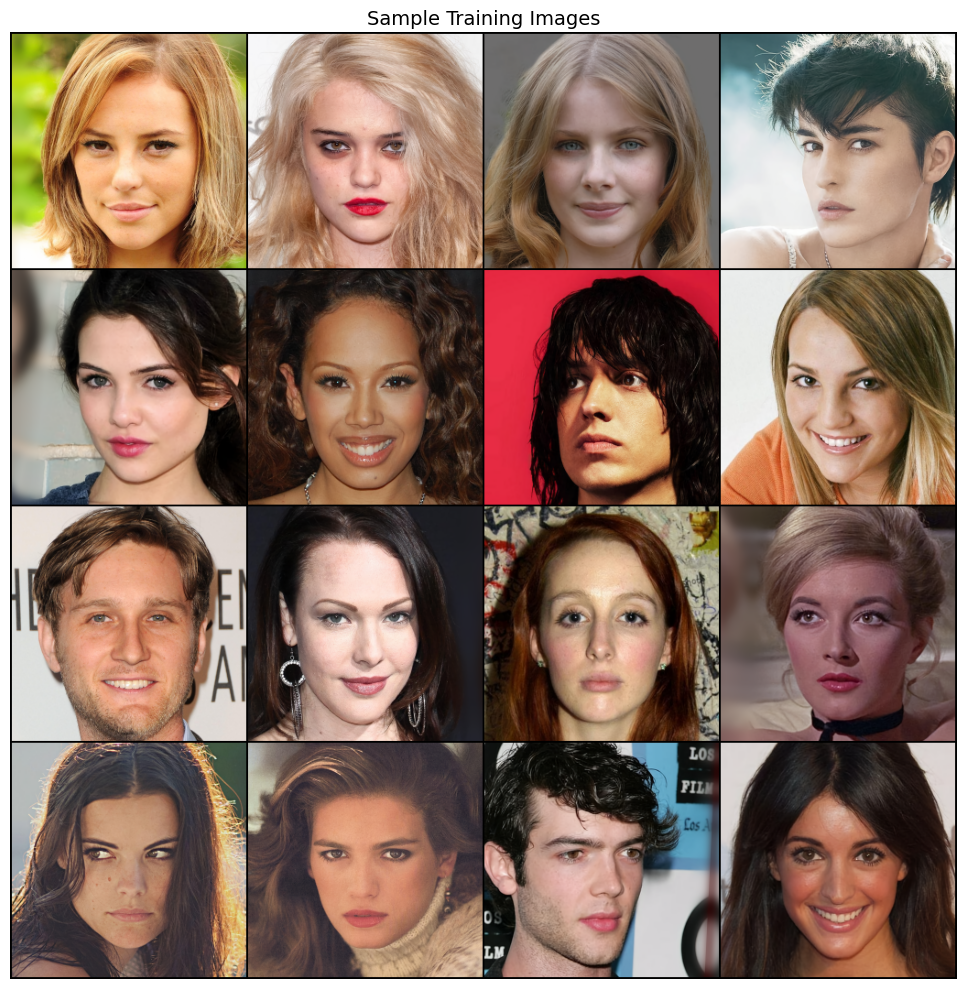

In [5]:
# ── Quick dataset sanity check ────────────────────────────────────
batch = next(iter(train_loader))
print(f'Batch shape : {batch.shape}')   # (B, 3, H, W)
print(f'Value range : [{batch.min():.2f}, {batch.max():.2f}]')

def denormalize(x):
    """[-1, 1] → [0, 1] for display."""
    return (x.clamp(-1, 1) + 1) / 2

grid = make_grid(denormalize(batch[:16]), nrow=4, padding=2)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples/training_samples.png', dpi=150)
plt.show()

---
## Part 2 — Forward Diffusion Process

The forward process gradually adds Gaussian noise to an image over **T** steps.
Thanks to the reparametrisation trick, we can sample any noisy step directly:

$$q(x_t | x_0) = \mathcal{N}(\sqrt{\bar\alpha_t}\, x_0,\; (1-\bar\alpha_t)\mathbf{I})$$

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\mathbf{I})$$

In [7]:
class NoiseScheduler:
    """
    Pre-computes beta/alpha schedules and provides helper tensors.
    Supports both linear and cosine schedules.
    """

    def __init__(self, T=300, beta_start=1e-4, beta_end=0.02, schedule='cosine', device='cpu'):
        self.T      = T
        self.device = device

        if schedule == 'linear':
            betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)
        elif schedule == 'cosine':
            steps  = T + 1
            t_vals = torch.linspace(0, T, steps) / T
            alphas = torch.cos((t_vals + 0.008) / 1.008 * math.pi / 2) ** 2
            alphas = alphas / alphas[0]
            betas  = 1 - (alphas[1:] / alphas[:-1])
            betas  = betas.clamp(0, 0.999)
        else:
            raise ValueError(f'Unknown schedule: {schedule}')

        alphas         = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_prev    = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        def reg(x): return x.to(device)

        self.betas               = reg(betas)
        self.alphas              = reg(alphas)
        self.alphas_cumprod      = reg(alphas_cumprod)
        self.alphas_cumprod_prev = reg(alphas_prev)

        self.sqrt_alphas_cumprod           = reg(alphas_cumprod.sqrt())
        self.sqrt_one_minus_alphas_cumprod = reg((1 - alphas_cumprod).sqrt())
        self.log_one_minus_alphas_cumprod  = reg((1 - alphas_cumprod).log())
        self.sqrt_recip_alphas             = reg((1 / alphas).sqrt())

        posterior_var = betas * (1 - alphas_prev) / (1 - alphas_cumprod)
        self.posterior_variance    = reg(posterior_var)
        self.posterior_log_variance= reg(posterior_var.clamp(min=1e-20).log())
        self.posterior_mean_coef1  = reg(betas * alphas_prev.sqrt() / (1 - alphas_cumprod))
        self.posterior_mean_coef2  = reg((1 - alphas_prev) * alphas.sqrt() / (1 - alphas_cumprod))

    def _gather(self, coef, t, x_shape):
        """Gather coef[t] and reshape to (B, 1, 1, 1) for broadcasting."""
        out = coef.gather(-1, t)
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0, t, noise=None):
        """Sample x_t from x_0 using the closed-form formula."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_a  = self._gather(self.sqrt_alphas_cumprod, t, x0.shape)
        sqrt_1a = self._gather(self.sqrt_one_minus_alphas_cumprod, t, x0.shape)
        return sqrt_a * x0 + sqrt_1a * noise, noise

    @torch.no_grad()
    def p_sample(self, model, xt, t_idx):
        """DDPM reverse step: sample x_{t-1} from x_t using the model."""
        t_tensor = torch.full((xt.shape[0],), t_idx, device=xt.device, dtype=torch.long)

        eps_pred = model(xt, t_tensor)

        coef1 = self._gather(self.sqrt_recip_alphas, t_tensor, xt.shape)
        coef2 = self._gather(self.betas, t_tensor, xt.shape) / \
                self._gather(self.sqrt_one_minus_alphas_cumprod, t_tensor, xt.shape)

        mean = coef1 * (xt - coef2 * eps_pred)

        if t_idx == 0:
            # Fix: clamp final output to valid range — prevents pure black images
            return mean.clamp(-1, 1)

        noise = torch.randn_like(xt)
        var   = self._gather(self.posterior_variance, t_tensor, xt.shape)
        # Fix: clamp each step output — prevents values exploding to ±inf
        return (mean + var.sqrt() * noise).clamp(-1, 1)

    @torch.no_grad()
    def p_sample_loop(self, model, shape, return_intermediates=False, n_intermediates=5):
        """Full reverse diffusion loop from pure noise to image."""
        model.eval()
        xt   = torch.randn(shape, device=self.device)
        imgs = []

        steps   = list(reversed(range(self.T)))
        save_at = set(steps[i] for i in
                      np.linspace(0, len(steps)-1, n_intermediates, dtype=int))

        for t in tqdm(steps, desc='Sampling', leave=False):
            xt = self.p_sample(model, xt, t)
            if return_intermediates and t in save_at:
                imgs.append(xt.cpu().clone())

        if return_intermediates:
            imgs.append(xt.cpu().clone())
            return xt, imgs
        return xt


scheduler = NoiseScheduler(T=T, beta_start=BETA_START, beta_end=BETA_END,
                            schedule=SCHEDULE, device=device)
print(f'Scheduler created  T={T}  schedule={SCHEDULE}')
print(f'β range: [{scheduler.betas.min():.5f}, {scheduler.betas.max():.4f}]')


AssertionError: Torch not compiled with CUDA enabled

In [ ]:
# ── Visualise 5+ forward noising steps ───────────────────────────
def visualise_forward(scheduler, x0, n_steps=8):
    steps     = np.linspace(0, scheduler.T - 1, n_steps, dtype=int)
    fig, axes = plt.subplots(1, n_steps + 1, figsize=(3*(n_steps+1), 3))

    axes[0].imshow(denormalize(x0[0]).permute(1,2,0).cpu().numpy())
    axes[0].set_title('Original', fontsize=9)
    axes[0].axis('off')

    for i, t in enumerate(steps):
        t_batch      = torch.full((1,), t, device=x0.device, dtype=torch.long)
        noisy, _     = scheduler.q_sample(x0[:1], t_batch)
        axes[i+1].imshow(denormalize(noisy[0]).permute(1,2,0).cpu().numpy())
        axes[i+1].set_title(f't={t}', fontsize=9)
        axes[i+1].axis('off')

    plt.suptitle('Forward Diffusion — Progressive Noising', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'samples/forward_diffusion.png', bbox_inches='tight', dpi=150)
    # Fix: was [plt.show](http://plt.show)() — corrupted hyperlink
    plt.show()


sample_batch = next(iter(train_loader)).to(device)
visualise_forward(scheduler, sample_batch, n_steps=8)


---
## Part 3 — U-Net Architecture

Architecture overview:
- **Input:** noisy image $x_t \in \mathbb{R}^{C\times H\times W}$ + timestep $t$
- **Output:** predicted noise $\hat\varepsilon \in \mathbb{R}^{C\times H\times W}$
- **Channel progression:** 64 → 128 → 256 (encoder) → 256 → 128 → 64 (decoder)
- Residual blocks, sinusoidal time embeddings, skip connections

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  U-NET BUILDING BLOCKS
# ══════════════════════════════════════════════════════════════════

# ── Fix 1: Safe GroupNorm helper ─────────────────────────────────
def get_groups(ch): return min(8, ch)


class SinusoidalPosEmb(nn.Module):
    """Sinusoidal timestep embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) * torch.arange(half, device=device) / (half - 1)
        )
        args = t[:, None].float() * freqs[None]
        # Fix 2: was [torch.cat](http://torch.cat) — corrupted hyperlink
        emb  = torch.cat([args.sin(), args.cos()], dim=-1)
        return emb


class TimeEmbedding(nn.Module):
    """Projects sinusoidal embedding through two linear layers."""
    def __init__(self, dim, out_dim):
        super().__init__()
        # Fix 3: was [self.net](http://self.net) — corrupted hyperlink
        self.net = nn.Sequential(
            SinusoidalPosEmb(dim),
            nn.Linear(dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, t):
        return self.net(t)


class ResBlock(nn.Module):
    """
    Residual block with Group Norm, SiLU, and time-step injection.
    Time embedding added via learned projection (AdaGN-style).
    """
    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        # Fix 4: use get_groups() instead of hardcoded 8
        self.norm1     = nn.GroupNorm(get_groups(in_ch),  in_ch)
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2     = nn.GroupNorm(get_groups(out_ch), out_ch)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act       = nn.SiLU()
        self.dropout   = nn.Dropout(dropout)
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch * 2),
        )
        self.shortcut  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        t_proj       = self.time_proj(t_emb)[:, :, None, None]
        scale, shift = t_proj.chunk(2, dim=1)
        h = self.norm2(h) * (1 + scale) + shift
        h = self.act(h)
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.shortcut(x)


class AttentionBlock(nn.Module):
    """Single-head self-attention with Group Norm."""
    def __init__(self, ch):
        super().__init__()
        # Fix 4 (continued): get_groups here too
        self.norm = nn.GroupNorm(get_groups(ch), ch)
        self.qkv  = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h   = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H*W)
        q, k, v = qkv.unbind(dim=1)
        scale = C ** -0.5
        attn  = torch.softmax(torch.bmm(q.transpose(1, 2), k) * scale, dim=-1)
        h_out = torch.bmm(v, attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(h_out)


class Downsample(nn.Module):
    """Strided convolution downsampler."""
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    """Bilinear upsample + convolution."""
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        return self.conv(x)


In [ ]:
#══════════════════════════════════════════════════════════════════
#  SIMPLIFIED U-NET
# ══════════════════════════════════════════════════════════════════

class UNet(nn.Module):
    """
    U-Net backbone for DDPM.
    Channel progression: base_ch → 2×base_ch → 4×base_ch
    Each level has 2 ResBlocks. Attention at the bottleneck.
    Time embedding injected into every ResBlock.
    """

    def __init__(self, in_ch=3, base_ch=64, time_emb_dim=256):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch*2, base_ch*4  # 64, 128, 256

        # ── Time embedding ────────────────────────────────────────
        self.time_emb = TimeEmbedding(base_ch, time_emb_dim)

        # ── Input projection ──────────────────────────────────────
        self.input_conv = nn.Conv2d(in_ch, ch1, 3, padding=1)

        # ── Encoder ───────────────────────────────────────────────
        self.enc1a = ResBlock(ch1, ch1, time_emb_dim)
        self.enc1b = ResBlock(ch1, ch1, time_emb_dim)
        self.down1 = Downsample(ch1)                         # H/2

        self.enc2a = ResBlock(ch1, ch2, time_emb_dim)
        self.enc2b = ResBlock(ch2, ch2, time_emb_dim)
        self.attn2 = AttentionBlock(ch2) # attention at 128ch
        self.down2 = Downsample(ch2)                         # H/4

        self.enc3a = ResBlock(ch2, ch3, time_emb_dim)
        self.enc3b = ResBlock(ch3, ch3, time_emb_dim)
        self.down3 = Downsample(ch3)                         # H/8

        # ── Bottleneck ────────────────────────────────────────────
        self.mid1 = ResBlock(ch3, ch3, time_emb_dim)
        self.attn = AttentionBlock(ch3)
        self.mid2 = ResBlock(ch3, ch3, time_emb_dim)

        # ── Decoder ───────────────────────────────────────────────
        self.up3   = Upsample(ch3)                           # H/4
        self.dec3a = ResBlock(ch3 + ch3, ch3, time_emb_dim)  # cat skip
        self.dec3b = ResBlock(ch3, ch3, time_emb_dim)

        self.up2   = Upsample(ch3)                           # H/2
        self.dec2a = ResBlock(ch3 + ch2, ch2, time_emb_dim)
        self.dec2b = ResBlock(ch2, ch2, time_emb_dim)
        self.attn_dec2 = AttentionBlock(ch2) # attention at 128ch decoder

        self.up1   = Upsample(ch2)                           # H
        self.dec1a = ResBlock(ch2 + ch1, ch1, time_emb_dim)
        self.dec1b = ResBlock(ch1, ch1, time_emb_dim)

        # ── Output projection ─────────────────────────────────────
        # Fix: was GroupNorm(8, ch1) — use get_groups() for safety
        self.output_norm = nn.GroupNorm(get_groups(ch1), ch1)
        self.output_conv = nn.Conv2d(ch1, in_ch, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, t):
        t_emb = self.time_emb(t)               # (B, time_emb_dim)

        # Encoder
        x0 = self.input_conv(x)
        e1 = self.enc1b(self.enc1a(x0, t_emb), t_emb)
        e2 = self.enc2b(self.enc2a(self.down1(e1), t_emb), t_emb)
        e2 = self.attn2(e2) # refine skip features
        e3 = self.enc3b(self.enc3a(self.down2(e2), t_emb), t_emb)

        # Bottleneck
        b  = self.mid1(self.down3(e3), t_emb)
        b  = self.attn(b)
        b  = self.mid2(b, t_emb)

        # Decoder with skip connections
        d3 = self.dec3b(self.dec3a(torch.cat([self.up3(b),  e3], dim=1), t_emb), t_emb)
        d2 = self.dec2b(self.dec2a(torch.cat([self.up2(d3), e2], dim=1), t_emb), t_emb)
        d2 = self.attn_dec2(d2) # refine decoder features
        d1 = self.dec1b(self.dec1a(torch.cat([self.up1(d2), e1], dim=1), t_emb), t_emb)

        out = self.output_conv(F.silu(self.output_norm(d1)))
        return out


# ── Build model ───────────────────────────────────────────────────
model = UNet(in_ch=CHANNELS, base_ch=BASE_CH, time_emb_dim=TIME_EMB_DIM).to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    print(f'Using {torch.cuda.device_count()} GPUs')

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters : {total_params:,}')
print(f'Trainable params : {train_params:,}')

with torch.no_grad():
    dummy_x   = torch.randn(2, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
    dummy_t   = torch.randint(0, T, (2,), device=device)
    dummy_out = model(dummy_x, dummy_t)
    print(f'Input  shape: {dummy_x.shape}')
    print(f'Output shape: {dummy_out.shape}')

---
## Part 4 — Training Setup & Loop

**Loss:** $\mathcal{L}_{simple} = \mathbb{E}_{t, x_0, \varepsilon}\left[\|\varepsilon - \varepsilon_\theta(x_t, t)\|^2\right]$

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  OPTIMIZER, SCHEDULER, SCALER, LOSS FN
# ══════════════════════════════════════════════════════════════════

LR = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=1e-4
)

# Fix 1: was [torch.optim.lr](http://torch.optim.lr)_scheduler — corrupted hyperlink
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR * 0.1
)

# Fix 2: was [torch.cuda.is](http://torch.cuda.is)_available — corrupted hyperlink
use_amp = torch.cuda.is_available()
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

def loss_fn(model, x0, scheduler):
    """Pure forward pass — NO autocast here.
    autocast is handled in the training loop's if use_amp block."""
    B         = x0.shape[0]
    t         = torch.randint(0, scheduler.T, (B,), device=x0.device)
    xt, noise = scheduler.q_sample(x0, t)
    eps_pred  = model(xt, t)   # no autocast here ✓
    return F.mse_loss(eps_pred, noise)

print(f'AMP enabled : {use_amp}')
print('Optimizer, scheduler, and scaler ready.')


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  RESUME FROM CHECKPOINT
#  Priority: latest epoch_XXXX.pt → fallback to best.pt
# ══════════════════════════════════════════════════════════════════

RESUME      = False
start_epoch = 66    # ← update this each time you resume
best_loss   = float('inf')
history     = {'train_loss': [], 'epoch_time': []}

if RESUME:
    # Try latest periodic checkpoint first, fall back to best.pt
    latest_ckpt = OUTPUT_DIR / f'checkpoints/epoch_{start_epoch - 1:04d}.pt'
    best_ckpt   = OUTPUT_DIR / 'checkpoints/best.pt'

    if latest_ckpt.exists():
        resume_ckpt = latest_ckpt
        print(f'▶ Found latest checkpoint: {latest_ckpt.name}')
    elif best_ckpt.exists():
        resume_ckpt = best_ckpt
        print(f'▶ Latest not found — falling back to: best.pt')
    else:
        resume_ckpt = None

    if resume_ckpt is not None:
        ckpt      = torch.load(resume_ckpt, map_location=device)
        raw_model = model.module if isinstance(model, nn.DataParallel) else model

        # Restore model weights
        raw_model.load_state_dict(ckpt['model_state'])

        # Restore optimizer — prevents grey collapse on resume
        optimizer.load_state_dict(ckpt['opt_state'])

        # Restore training state
        start_epoch = ckpt['epoch'] + 1
        best_loss   = ckpt['loss']
        history['train_loss'] = ckpt.get('train_loss_history', [best_loss] * ckpt['epoch'])
        history['epoch_time']  = ckpt.get('epoch_time_history',  [0.0]      * ckpt['epoch'])

        print(f'  ✓ Model weights    restored')
        print(f'  ✓ Optimizer state  restored')
        print(f'  ✓ Loaded epoch {ckpt["epoch"]:>4} | best_loss = {best_loss:.5f}')
        print(f'  ✓ Training starts  from epoch {start_epoch}')
    else:
        print('⚠ No checkpoint found anywhere — starting from scratch')
        start_epoch = 1
else:
    print('▶ Starting fresh from epoch 1')


In [ ]:
from tqdm.notebook import tqdm

# ══════════════════════════════════════════════════════════════════
#  TRAINING LOOP
# ══════════════════════════════════════════════════════════════════

# Points at the last saved periodic checkpoint so the loop
# deletes it automatically when the next one saves.
# ↓ Update this to your latest epoch_XXXX.pt each time you restart.
last_periodic_ckpt = OUTPUT_DIR / 'checkpoints/epoch_0060.pt'

epoch_pbar = tqdm(range(start_epoch, EPOCHS + 1), desc='Epochs')

for epoch in epoch_pbar:
    model.train()
    epoch_loss = 0.0
    t0         = time.time()

    batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False)

    for batch in batch_pbar:
        x0 = batch.to(device, non_blocking=True)
        optimizer.zero_grad()

        loss = loss_fn(model, x0, scheduler)

        if torch.isnan(loss):
            tqdm.write(f'  ✗ NaN loss at epoch {epoch} — skipping batch')
            optimizer.zero_grad()
            continue

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
           
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            
            optimizer.step()

        epoch_loss += loss.item()
        batch_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    batch_pbar.close()
    scheduler_lr.step()

    avg_loss   = epoch_loss / len(train_loader)
    epoch_time = time.time() - t0
    history['train_loss'].append(avg_loss)
    history['epoch_time'].append(epoch_time)

    epoch_pbar.set_postfix({
        'loss' : f'{avg_loss:.4f}',
        'best' : f'{min(history["train_loss"]):.4f}',
        'time' : f'{epoch_time:.1f}s',
    })

    tqdm.write(f'Epoch {epoch:>3}/{EPOCHS}  |  loss: {avg_loss:.4f}  |  best: {min(history["train_loss"]):.4f}  |  {epoch_time:.1f}s')

    # ── save best checkpoint (always kept, never deleted) ─────
    if avg_loss < best_loss:
        best_loss = avg_loss
        raw_model = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({
            'epoch'              : epoch,
            'model_state'        : raw_model.state_dict(),
            'opt_state'          : optimizer.state_dict(),
            'loss'               : best_loss,
            'train_loss_history' : history['train_loss'],
            'epoch_time_history' : history['epoch_time'],
        }, OUTPUT_DIR / 'checkpoints/best.pt')
        tqdm.write(f'         ✓ best checkpoint saved (loss={best_loss:.4f})')

    # ── periodic checkpoint: save new, delete previous ────────
    if epoch % SAVE_EVERY == 0:
        raw_model = model.module if isinstance(model, nn.DataParalle2l) else model
        new_ckpt  = OUTPUT_DIR / f'checkpoints/epoch_{epoch:04d}.pt'

        # 1. Save new checkpoint first
        torch.save({
            'epoch'              : epoch,
            'model_state'        : raw_model.state_dict(),
            'opt_state'          : optimizer.state_dict(),
            'loss'               : avg_loss,
            'train_loss_history' : history['train_loss'],
            'epoch_time_history' : history['epoch_time'],
        }, new_ckpt)
        tqdm.write(f'         💾 checkpoint saved → epoch_{epoch:04d}.pt')

        # 2. Delete the previous periodic checkpoint
        if last_periodic_ckpt is not None and last_periodic_ckpt.exists():
            last_periodic_ckpt.unlink()
            tqdm.write(f'         🗑 deleted old → {last_periodic_ckpt.name}')

        # 3. Track new checkpoint for next deletion
        last_periodic_ckpt = new_ckpt

    # ── periodic samples ──────────────────────────────────────
    if epoch % SAMPLE_EVERY == 0:
        raw_model  = model.module if isinstance(model, nn.DataParallel) else model2
        gen_images = scheduler.p_sample_loop(
            raw_model, (4, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
        )
        grid = make_grid(denormalize(gen_images), nrow=4, padding=2)
        save_image(grid, OUTPUT_DIR / f'samples/gen_epoch_{epoch:04d}.png')
        tqdm.write(f'         📷 samples saved → gen_epoch_{epoch:04d}.png')

tqdm.write(f'\nDone. Best loss: {best_loss:.4f}')


In [ ]:
# ── Loss curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], linewidth=2, color='steelblue', label='Train loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples/loss_curve.png', dpi=150)
plt.show()

---
## Part 5 — Image Reconstruction (Core Task)

1. Load a target image
2. Run the full reverse diffusion loop (start from pure noise)
3. Display side-by-side: Target vs Reconstructed

In [ ]:
# ── Load best checkpoint ──────────────────────────────────────────
ckpt = torch.load(OUTPUT_DIR / 'checkpoints/best.pt', map_location=device)
raw_model = model.module if isinstance(model, nn.DataParallel) else model
raw_model.load_state_dict(ckpt['model_state'])
raw_model.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (loss={ckpt["loss"]:.5f})')

In [ ]:
# ── Pick a target image from the dataset ─────────────────────────
target_tensor = dataset[0].unsqueeze(0).to(device)  # shape: (1, C, H, W)

# Run full reverse diffusion
with torch.no_grad():
    reconstructed, intermediates = scheduler.p_sample_loop(
        raw_model,
        (1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE),
        return_intermediates=True,
        n_intermediates=5,
    )

# ── Side-by-side comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(denormalize(target_tensor[0].cpu()).permute(1,2,0).numpy())
axes[0].set_title('Target Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(denormalize(reconstructed[0].cpu()).permute(1,2,0).numpy())
axes[1].set_title('Generated Image', fontsize=12)
axes[1].axis('off')

plt.suptitle('Part 5 — Reconstruction: Target vs Generated', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples/reconstruction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Reconstruction complete.')

---
## Part 6 — Image Generation (≥ 5 New Images)

In [ ]:
N_GEN = 8   # how many images to generate

with torch.no_grad():
    generated = scheduler.p_sample_loop(
        raw_model,
        (N_GEN, CHANNELS, IMAGE_SIZE, IMAGE_SIZE),
    )

grid = make_grid(denormalize(generated.cpu()), nrow=4, padding=4)

plt.figure(figsize=(14, 7))
plt.imshow(grid.permute(1,2,0).numpy())
plt.axis('off')
plt.title(f'Part 6 — {N_GEN} Generated Images from Pure Noise', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples/generated_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Generation complete.')

---
## Visualisation Module

Shows:
- **5 forward diffusion steps** (original → fully noisy)
- **5 intermediate denoising steps** (noise → image)
- **5 final generated outputs**

In [ ]:
def full_visualisation(model, scheduler, dataset, n_show=5, image_size=IMAGE_SIZE):
    """Complete visualisation: forward steps + reverse steps + generated outputs."""

    x0   = dataset[0].unsqueeze(0).to(device)

    # ── 1. Forward diffusion steps ────────────────────────────────
    fwd_steps   = np.linspace(0, scheduler.T - 1, n_show, dtype=int)
    fwd_images  = []
    for t in fwd_steps:
        t_b = torch.full((1,), t, device=device, dtype=torch.long)
        noisy, _ = scheduler.q_sample(x0, t_b)
        fwd_images.append(denormalize(noisy[0].cpu()))

    # ── 2. Reverse denoising steps ────────────────────────────────
    model.eval()
    with torch.no_grad():
        _, rev_images = scheduler.p_sample_loop(
            model, (1, CHANNELS, image_size, image_size),
            return_intermediates=True, n_intermediates=n_show
        )
    rev_images = [denormalize(img[0]) for img in rev_images]

    # ── 3. Final generated images ─────────────────────────────────
    with torch.no_grad():
        gen = scheduler.p_sample_loop(
            model, (n_show, CHANNELS, image_size, image_size)
        )
    gen_images = [denormalize(gen[i].cpu()) for i in range(n_show)]

    # ── Plot ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(n_show * 3, 11))
    gs  = gridspec.GridSpec(3, n_show, figure=fig, hspace=0.4)

    row_titles = [
        f'Forward diffusion (noising) — {n_show} steps',
        f'Reverse diffusion (denoising) — {n_show} steps',
        f'{n_show} generated images',
    ]
    image_rows = [fwd_images, rev_images, gen_images]

    for row, (title, imgs) in enumerate(zip(row_titles, image_rows)):
        fig.text(0.5, 0.97 - row * 0.34, title, ha='center',
                 fontsize=12, fontweight='bold')
        for col, img in enumerate(imgs[:n_show]):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(img.permute(1,2,0).numpy().clip(0,1))
            ax.axis('off')
            if row == 0:
                ax.set_title(f't={fwd_steps[col]}', fontsize=8)

    plt.savefig(OUTPUT_DIR / 'samples/full_visualisation.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/samples/full_visualisation.png')


full_visualisation(raw_model, scheduler, dataset, n_show=5)

---
## Quantitative Evaluation — PSNR & SSIM

In [ ]:
def compute_metrics(generated_tensor, target_tensor):
    """
    Compute PSNR and SSIM between generated and target images.
    Inputs: tensors in [-1, 1], shape (B, C, H, W)
    """
    gen_np  = denormalize(generated_tensor).permute(0,2,3,1).cpu().numpy()  # (B,H,W,C)
    tgt_np  = denormalize(target_tensor).permute(0,2,3,1).cpu().numpy()

    psnr_scores, ssim_scores = [], []

    for g, t in zip(gen_np, tgt_np):
        g_f = g.astype(np.float64)
        t_f = t.astype(np.float64)
        psnr_scores.append(psnr_metric(t_f, g_f, data_range=1.0))
        ssim_scores.append(ssim_metric(t_f, g_f, data_range=1.0, channel_axis=2,
                                       win_size=min(7, IMAGE_SIZE-1 if (IMAGE_SIZE-1)%2==1
                                                     else IMAGE_SIZE-2)))

    return {
        'psnr_mean': np.mean(psnr_scores),
        'psnr_std' : np.std(psnr_scores),
        'ssim_mean': np.mean(ssim_scores),
        'ssim_std' : np.std(ssim_scores),
        'psnr_all' : psnr_scores,
        'ssim_all' : ssim_scores,
    }


# Evaluate on first 8 images from dataset
N_EVAL  = 8
targets = torch.stack([dataset[i] for i in range(N_EVAL)]).to(device)

with torch.no_grad():
    generated_eval = scheduler.p_sample_loop(
        raw_model, (N_EVAL, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    )

metrics = compute_metrics(generated_eval, targets)

print('=' * 50)
print('  Quantitative Evaluation Results')
print('=' * 50)
print(f'  PSNR : {metrics["psnr_mean"]:.2f} ± {metrics["psnr_std"]:.2f} dB')
print(f'  SSIM : {metrics["ssim_mean"]:.4f} ± {metrics["ssim_std"]:.4f}')
print('=' * 50)

In [ ]:
# ── Per-image metrics bar chart ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

x_idx = np.arange(N_EVAL)
ax1.bar(x_idx, metrics['psnr_all'], color='steelblue', alpha=0.8)
ax1.axhline(metrics['psnr_mean'], color='red', ls='--', label=f'Mean={metrics["psnr_mean"]:.2f}')
ax1.set_xlabel('Image index')
ax1.set_ylabel('PSNR (dB)')
ax1.set_title('PSNR per Image')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(x_idx, metrics['ssim_all'], color='darkorange', alpha=0.8)
ax2.axhline(metrics['ssim_mean'], color='red', ls='--', label=f'Mean={metrics["ssim_mean"]:.4f}')
ax2.set_xlabel('Image index')
ax2.set_ylabel('SSIM')
ax2.set_title('SSIM per Image')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Quantitative Evaluation — PSNR & SSIM', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples/metrics.png', dpi=150)
plt.show()

---
## Part 10 — Gradio App Deployment

Interactive app that:
- Starts from random noise
- Generates an image via reverse diffusion
- Displays intermediate denoising steps as a gallery

In [ ]:
import gradio as gr
import io
from PIL import Image as PILImage


def tensor_to_pil(t):
    """Convert (C,H,W) tensor in [-1,1] to PIL Image."""
    arr = (denormalize(t).permute(1,2,0).numpy() * 255).clip(0,255).astype(np.uint8)
    return PILImage.fromarray(arr)


def generate_image(n_intermediates: int, seed: int):
    """
    Gradio callback: generates one image and returns:
    - Final generated image (PIL)
    - Gallery of intermediate denoising steps (list of PIL)
    """
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))

    raw = model.module if isinstance(model, nn.DataParallel) else model
    raw.eval()

    with torch.no_grad():
        final, intermediates = scheduler.p_sample_loop(
            raw,
            (1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE),
            return_intermediates=True,
            n_intermediates=int(n_intermediates),
        )

    final_pil = tensor_to_pil(final[0].cpu())
    step_pils = [tensor_to_pil(img[0]) for img in intermediates]

    return final_pil, step_pils


with gr.Blocks(title='DDPM Image Generator') as demo:
    gr.Markdown("""
    # 🎨 DDPM Image Generator
    Generates images from pure Gaussian noise using a trained Denoising Diffusion Probabilistic Model.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            n_steps_slider = gr.Slider(
                minimum=3, maximum=10, value=5, step=1,
                label='Intermediate denoising steps to display'
            )
            seed_input = gr.Number(value=42, label='Random seed', precision=0)
            gen_btn    = gr.Button('Generate Image', variant='primary')

        with gr.Column(scale=2):
            output_img = gr.Image(label='Generated Image', type='pil')

    gr.Markdown('### Intermediate Denoising Steps')
    gallery = gr.Gallery(
        label='Denoising progress (noise → image)',
        show_label=True,
        columns=5,
        height='auto',
    )

    gen_btn.click(
        fn=generate_image,
        inputs=[n_steps_slider, seed_input],
        outputs=[output_img, gallery],
    )

    gr.Markdown("""
    ---
    **How it works:**
    1. Samples pure Gaussian noise $x_T \\sim \\mathcal{N}(0,I)$
    2. Runs the learned reverse process $p_\\theta(x_{t-1}|x_t)$ for T steps
    3. Returns the final denoised image $\\hat{x}_0$
    """)


# Launch the app
demo.launch(share=True, debug=False)

---
## Summary

| Component | Implementation |
|-----------|---------------|
| **Forward process** | Closed-form q(xₜ\|x₀) with cosine/linear β schedule |
| **Backbone** | U-Net: 64→128→256 channels, ResBlocks, skip connections |
| **Time embedding** | Sinusoidal → Linear → SiLU → Linear |
| **Attention** | Self-attention at bottleneck |
| **Loss** | MSE(ε, ε̂θ) — simple DDPM objective |
| **Optimizer** | AdamW + Cosine LR scheduler |
| **Mixed precision** | torch.cuda.amp (GradScaler + autocast) |
| **Multi-GPU** | nn.DataParallel (T4 ×2 compatible) |
| **Sampling** | DDPM ancestral sampler |
| **Evaluation** | PSNR + SSIM (skimage.metrics) |
| **App** | Gradio with gallery of intermediate steps |